## Import necessary libraries & import data

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [156]:
# orders_qu.csv
url = "https://drive.google.com/file/d/1sW32ox48H51IOJOm_y6rJxpExpVNyJe2/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

orders_df = orders.copy()

# orderlines_qu.csv
url = "https://drive.google.com/file/d/18EEFxlaM8IdGX1XIqLMM1qqsYOnVCYQb/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)

orderlines_df = orderlines.copy()

# products_qu.csv
url = "https://drive.google.com/file/d/1KAU235y8NmRW2TfdBN9jUbJwDfceUnb3/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

products_df = products.copy()

# brands_qu.csv
url = "https://drive.google.com/file/d/11u-yJ9JLXMNEi6glyjQrY2j0U6Xl8KN3/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

brands_df = brands.copy()

## Creating a discounts dataframe for simplification of analysis

In [220]:
discounts_df = orderlines_df.merge(products_df,on='sku',how='left')
discounts_df['discount'] = discounts_df['price'] - discounts_df['unit_price']
discounts_df['discount_rate'] = discounts_df['discount']/ discounts_df['price'] *100
discounts_df['short'] = discounts_df['sku'].str[:3]
discounts_df = discounts_df.merge(brands_df,on='short', how='left')
discounts_df = discounts_df.rename(columns={'long': 'brand'})
#discounts_df

## Set display format

In [157]:
pd.set_option("display.float_format", lambda x: "%.2f" % x) # displays numbers with only two decimal places
pd.set_option("display.max_rows", 1000) # display up to 1000 rows at once
pd.set_option('display.max.colwidth',None)
pd.set_option('display.width',None)

## 1. Checking the time period of the dataset

In [158]:
# changing data types to fit the definition
orderlines_df['date'] = pd.to_datetime(orderlines_df['date'])
orders_df['created_date'] = pd.to_datetime(orders_df['created_date'])

In [159]:
time_period = orderlines_df['date'].max() - orderlines_df['date'].min()
days        = time_period.components.days
hours       = time_period.components.hours
minutes     = time_period.components.minutes
seconds     = time_period.components.seconds
print(f'The time period of the dataset is {days} days, {hours} hours, {minutes} minutes and {seconds} seconds.')

The time period of the dataset is 437 days, 10 hours, 11 minutes and 57 seconds.


- check if this matches the time_period in orders_df

In [160]:
time_period == (orders_df['created_date'].max() - orders_df['created_date'].min())

False

In [161]:
orderlines_df.loc[orderlines_df['date'] == orderlines_df['date'].max(), :]

,order_id,product_quantity,sku,unit_price,date,unit_total
54124,527112,1,APP0698,9.99,2018-03-14 11:58:13,9.99


In [162]:
orders_df.loc[orders_df['created_date'] == orders_df['created_date'].max(), :]

,order_id,created_date,total_paid,state
41483,527112,2018-03-14 12:03:52,14.98,Completed


- The orders_df timestamps one entry of the earliest time/ first product when the order was initialized. Thus, orderlines_df makes more sense to use as it specifies the time for each product in an order

## 2. Calculating the overall revenue

In [163]:
# using the orderlines table
overall_revenue = orderlines_df['unit_total'].sum()
print(f'The overall revenue for sold orders is {overall_revenue:.2f} EUROS')

The overall revenue for sold orders is 7888086.33 EUROS


In [164]:
# using the orders table
revenue = orders_df['total_paid'].sum()
overall_revenue < revenue

np.True_

- The overall revenue is calculated using the orderlines_df dataset since orders_df carries shipping costs/ gift wrapping costs etc thus not exclusively displaying ENIAC's revenue

## 3. Looking for seasonal patterns

- We first need to get an impression of sales across the dataset

<Axes: title={'center': 'Sales across the Dataset'}, xlabel='Dates', ylabel='Number of Orders'>

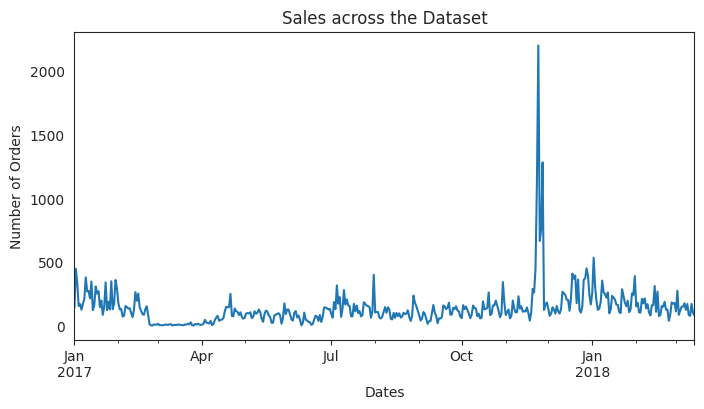

In [165]:
orderlines_df.resample('D', on='date')['product_quantity'].sum().plot(title=('Sales across the Dataset'),figsize=(8,4),xlabel=('Dates'),ylabel='Number of Orders')

- Narrowing down the visualisation to one month  might give a better impression

<Axes: xlabel='Months', ylabel='Sold Products'>

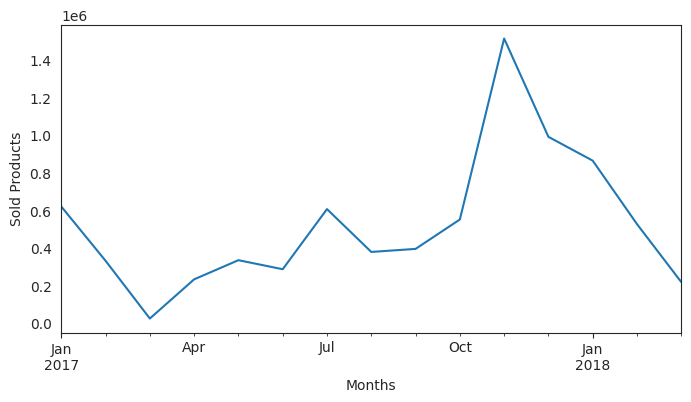

In [166]:
orderlines_df.resample('ME',on='date')['unit_total'].sum().plot(xlabel='Months', ylabel='Sold Products',figsize=(8,4))

- My take is it is not enough data to compare seasonality but we can take a look at days of the week (may be more sales over the weekend) and also check the peak (if it correlates to black Friday season)
- I looked at shopping on each week day but don't see that it informs much, other than that may be most people shop in the middle of the week rather than weekends.
- This is why I just commented it out but you can explore it

In [167]:
#orderlines_df['day_of_week'] = orderlines_df['date'].dt.day_name()
#orderlines_df.groupby('day_of_week')['product_quantity'].sum().plot(  kind='bar', figsize=(12,6), title='Sales by Day of Week', xlabel='Day', ylabel='Total Units Sold')

## Black Week 2017 (20 to 27 Nov, 2017)

- May be it makes more sense to zoom in on that peak

In [219]:
# Given black Fiday 2027 was between 20 to 27 November
mask = discounts_df['date'].between('2017-11-20','2017-11-28')
black_friday = discounts_df.loc[mask,:]

,order_id,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category,discount,discount_rate,short,brand
30056,428777,1,APP1922,154.00,2017-11-20 00:08:11,154.00,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384,,25.00,13.97,APP,Apple
30057,428782,1,SPE0137,39.99,2017-11-20 00:09:51,39.99,"Speck SeeThru Satin MacBook Air Case 13 ""Black",MacBook Air 13 inch casing satin.,49.90,13835403,,9.91,19.86,SPE,Spek SeeThru
30058,428782,1,APP1138,51.00,2017-11-20 00:11:01,51.00,Apple Leather Case Cover iPhone 6 / 6S Black,ultrathin leather case and microfiber premium for iPhone 6 / 6S,55.00,11865403,phone case,4.00,7.27,APP,Apple
30059,428784,1,APP1922,154.00,2017-11-20 00:12:01,154.00,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384,,25.00,13.97,APP,Apple
30060,428786,1,APP1922,154.00,2017-11-20 00:12:16,154.00,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384,,25.00,13.97,APP,Apple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36204,450028,2,CRU0053,229.90,2017-11-27 23:51:30,459.80,Disk 1TB SSD Crucial MX300,1050GB SSD Hard Drive SATA 3.0 (6Gb / s) for Mac and PC,293.34,12215397,,63.44,21.63,CRU,Crucial
36205,450037,1,NTE0103,80.74,2017-11-27 23:54:21,80.74,"NewerTech NuPower 55 W Battery for MacBook Air 13 ""late 2010 - early 2015",Battery Compatible with MacBook Air 13 inch from late 2010 to early 2015,119.99,10142,,39.25,32.71,NTE,NewerTech
36206,446769,1,IKM0064,51.29,2017-11-27 23:54:25,51.29,IK Multimedia Grip iKlip Pro Camera Support,Multipurpose support (tripod empuÌ ± Adura selfie stick and support) to take full advantage of your iPhone,59.99,11905404,,8.70,14.50,IKM,IK Multimedia
36207,448711,1,APP0927,17.09,2017-11-27 23:54:45,17.09,EarPods Apple Headphones with Remote and Mic (OEM),EarPods headphones Apple iPhone iPad and iPod with microphone and remote control,35.00,5384,,17.91,51.17,APP,Apple


<Axes: title={'center': 'Sales during Black Friday Week'}, xlabel='Dates of the Week', ylabel='Number of Orders'>

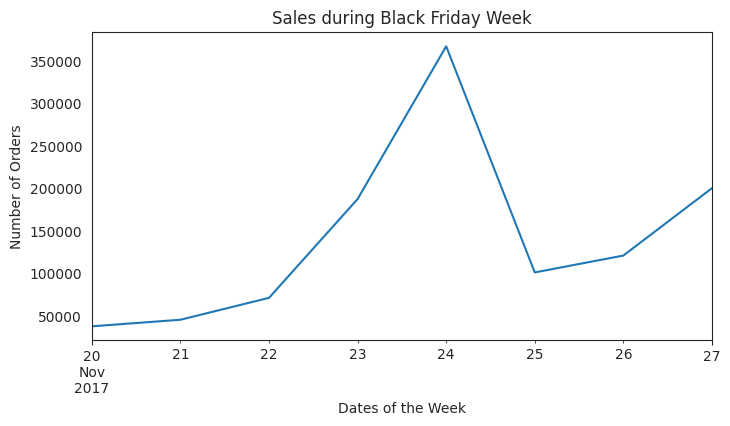

In [218]:
black_friday.resample('D', on='date')['unit_total'].sum().plot(title=('Sales during Black Friday Week'),figsize=(8,4),xlabel=('Dates of the Week'),ylabel='Number of Orders')

- Black Friday recorded the most sales. 2017-11-24 has over 2000 sales, as a result November also ends with the highest sales

## Products sold the most

In [170]:
most_sold = orderlines_df.groupby('sku',as_index=False)['product_quantity'].sum().sort_values('product_quantity',ascending=False).head(10) # sorting products by the number of total sold units
most_sold_name = most_sold.merge(products_df,on='sku',how='inner') # merging to get product names
most_sold_name.drop(['price', 'type'],axis=1)

,sku,product_quantity,name,desc
0,APP1190,957,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.
1,APP0698,821,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod
2,APP1922,540,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box
3,APP0927,491,EarPods Apple Headphones with Remote and Mic (OEM),EarPods headphones Apple iPhone iPad and iPod with microphone and remote control
4,WDT0183,478,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).
5,CRU0051,339,Crucial MX300 525GB SSD Disk,SSD 525GB SATA Hard Disk 3.0 (6Gb / s) for Mac and PC
6,SAM0074,337,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA III with 3D V-NAND.
7,APP2446,270,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray
8,CRU0050,260,Crucial MX300 275GB SSD Disk,SSD 275GB SATA Hard Disk 3.0 (6Gb / s) for Mac and PC
9,NTE0013,259,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",Adapter HDD / SSD 2.5 SATA 3.5 compatible with Mac Pro.


## Products generating the most revenue

In [171]:
most_revenue = orderlines_df.groupby('sku',as_index=False)['unit_total'].sum().sort_values('unit_total',ascending=False).head(10) # dorting the top 10 highest revenue generating products
most_revenue_name = most_revenue.merge(products_df,on='sku',how='inner') # merging to get the product names
most_revenue_name.drop(['price', 'type'],axis=1)

,sku,unit_total,name,desc
0,LGE0044,136515.81,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",99% Professional Monitor sRGB color calibrator cable USB-C connection for Mac and PC
1,APP2446,104560.64,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray
2,APP1922,86960.26,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box
3,APP2477,85301.93,Apple iPhone 64GB Space Gray 8,Apple iPhone 64GB 8 Color Space Gray
4,APP1970,81124.76,Apple iPhone 32GB Space Gray,New iPhone SE with 4-inch screen 32 free GB.
5,APP2072,74964.06,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",laptop MacBook Air 13 inch i5 18GHz 8GB RAM and 128GB SSD
6,APP2485,70721.79,Apple iPhone 8 Plus 64GB Gold,Apple iPhone 8 Plus 64GB Gold color
7,WDT0183,65848.36,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).
8,APP2483,60090.08,Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray
9,APP2479,52981.19,Apple iPhone 64GB Gold 8,Apple iPhone 64GB 8 in Gold


## A Focus on Discounts

In [173]:
# Exploring discount limits
discounts_df['discount_rate'].max(), discounts_df['discount_rate'].min()

(97.14081486776269, -212.26533166458074)

## Relation between discount and revenue

- I looked at a relation between revenue(sum) and discount(mean)
- Using daily data misinforms the trend (in my opinion)
- I then chose to use months (displayed below as black_friday_chart) and quarters

<Axes: title={'center': 'discount rate and revenue are not directly propotional to each other\n therefore suggesting other influencing factors'}, xlabel='date'>

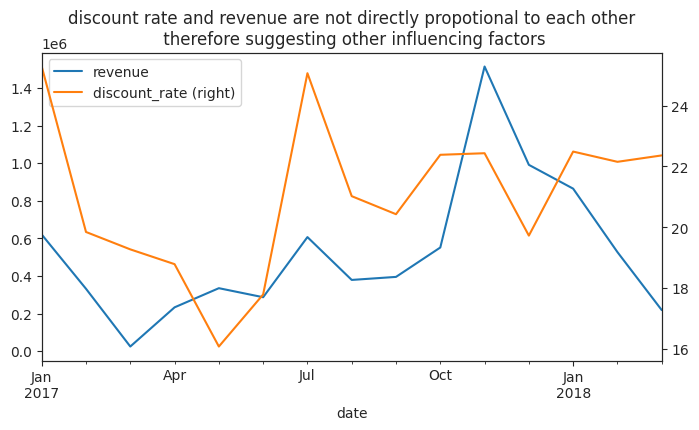

In [174]:
# resample into month end to plot both revenue and discount rate
months_new = discounts_df.resample('ME', on='date').agg(discount_rate=('discount_rate', 'mean'), revenue=('unit_total', 'sum')).reset_index()
months_new.plot(x='date',y=['revenue','discount_rate'],secondary_y='discount_rate',figsize=(8,4),title='discount rate and revenue are not directly propotional to each other\n therefore suggesting other influencing factors')

In [175]:
# Quarters
mean_discount = discounts_df.resample('QE', on='date').agg(
    discount_rate=('discount_rate', 'mean'),
    revenue=('unit_total', 'sum')
).reset_index()

<Axes: title={'center': 'Comparison between Revenue & Discount Rate'}, xlabel='date'>

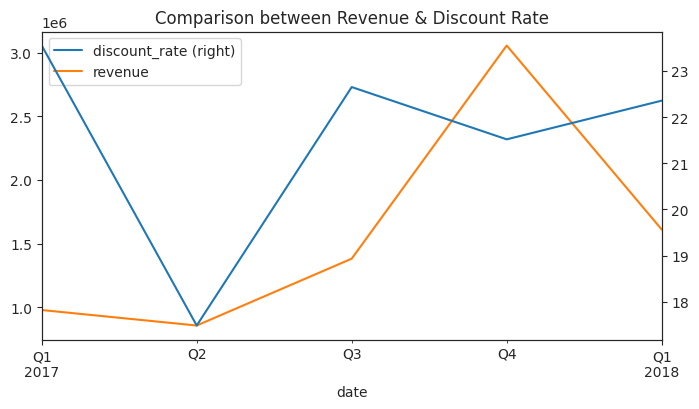

In [176]:
mean_discount.plot(x='date',y=['discount_rate','revenue'],secondary_y='discount_rate',figsize=(8,4),title='Comparison between Revenue & Discount Rate')


In [177]:
mean_discount_daily = discounts_df.resample('D', on='date').agg(
    discount_rate=('discount_rate', 'mean'),
    revenue=('unit_total', 'sum')
).reset_index()

<Axes: title={'center': 'Comparison between Daily Revenue & Discount Rate'}, xlabel='date'>

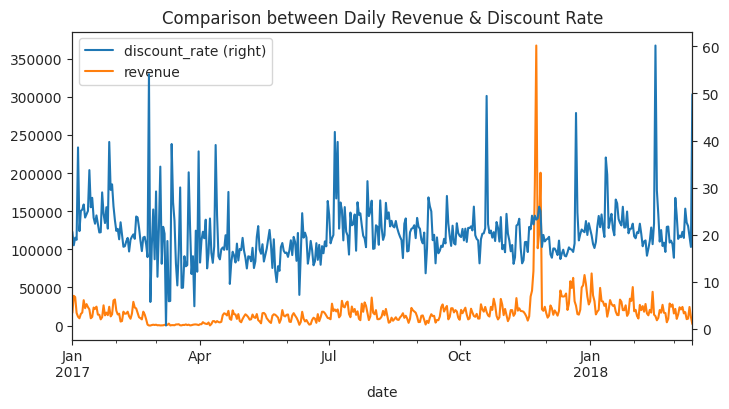

In [178]:
mean_discount_daily.plot(x='date',y=['discount_rate','revenue'],secondary_y='discount_rate',figsize=(8,4),title='Comparison between Daily Revenue & Discount Rate')

###Let us try to use the pandas correlation method

In [179]:
discounts_df[['discount_rate', 'unit_total']].corr(method='pearson',min_periods=30)

,discount_rate,unit_total
discount_rate,1.00,-0.30
unit_total,-0.30,1.00


- Mathematically, the deduction that revenue is not reliant on discount is proven. The scatter plot below shows the lack of this correlation.

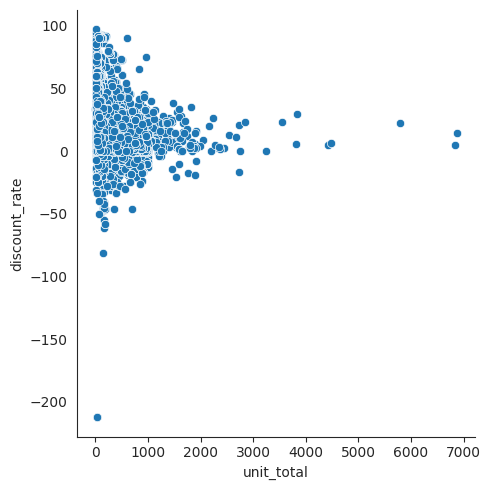

In [180]:
sns.relplot(kind='scatter', data=discounts_df,x='unit_total',y='discount_rate')

### Let us use the most revenue generating brand to compare discount trend as well

<Axes: title={'center': 'Comparison between Revenue & Discount Rate for Apple'}, xlabel='date'>

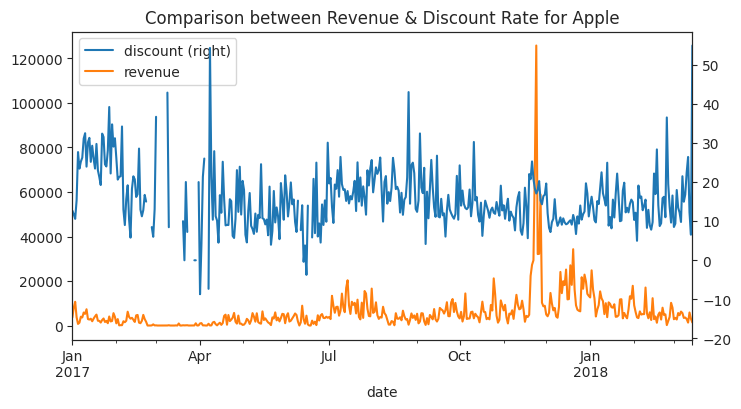

In [181]:
# creating a table for Apple products only
apple_corr = discounts_df.loc[discounts_df['brand']=='Apple',:]
apple_corr.resample('D',on='date').agg(
    discount=('discount_rate', 'mean'),
    revenue=('unit_total', 'sum')
).reset_index().plot(x='date',y=['discount','revenue'],secondary_y='discount',figsize=(8,4),title='Comparison between Revenue & Discount Rate for Apple')

- It appears discount is not the main driver for sales. In fact even for the most selling brand, the higher the discount, the less the revenue made. While there is correlation betwee the two it appears there are other factors driving sale more than discounts

### May be we should compare discounts with number of orders

<Axes: title={'center': 'Comparison between Number of Orders & Discount Rate'}, xlabel='date'>

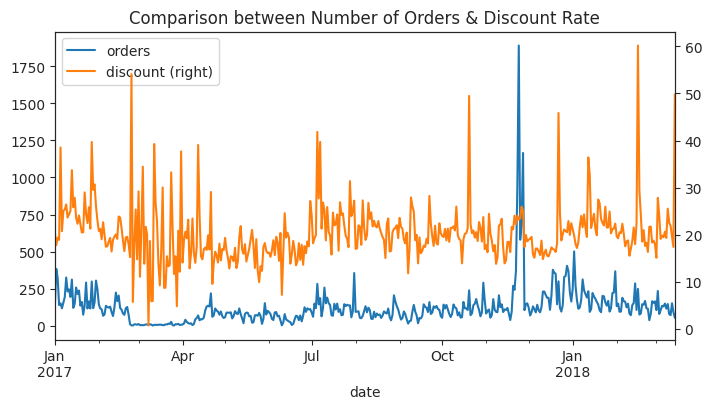

In [182]:
discounts_df.resample('D',on='date').agg(discount=('discount_rate', 'mean'),
    orders=('order_id', 'count')).reset_index().plot(x='date',y=['orders','discount'],secondary_y='discount',figsize=(8,4),title='Comparison between Number of Orders & Discount Rate')

<Axes: title={'center': 'Comparison between Number of Orders & Revenue'}, xlabel='date'>

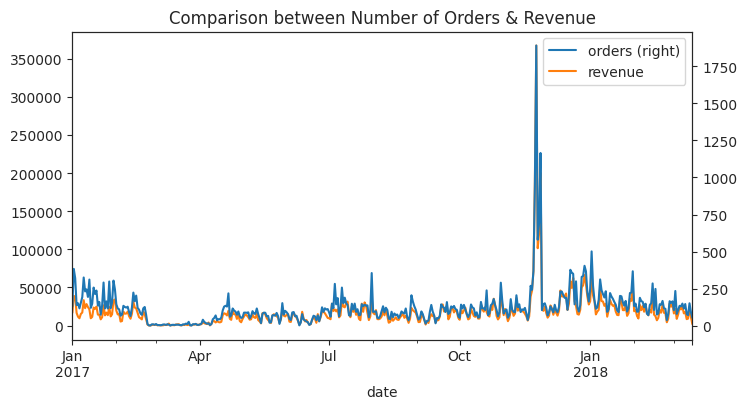

In [183]:
discounts_df.resample('D',on='date').agg(revenue=('unit_total', 'sum'),
    orders=('order_id', 'count')).reset_index().plot(x='date',y=['orders','revenue'],secondary_y='orders',figsize=(8,4),title='Comparison between Number of Orders & Revenue')

In [184]:
daily_values = discounts_df.resample('D', on='date').agg(
    revenue=('unit_total', 'sum'),
    orders=('order_id', 'count')
).reset_index()

daily_values[['revenue', 'orders']].corr(method='pearson')

,revenue,orders
revenue,1.00,0.97
orders,0.97,1.00


- Revenue is directly proportional to the number of orders placed

## Further Analysis

### Question: How many times has a product been discounted or how many products are being discounted?

- group by product and take the max discount for it (at any point in time) to see which product has had the highest discount

In [185]:
max_discount_per_sku = discounts_df.groupby('sku',as_index=False)['discount'].max().sort_values(by='discount',ascending=False)
max_discount_sku = max_discount_per_sku.merge(products_df,how='inner',on='sku')
max_discount_sku = max_discount_sku.rename(columns={'discount': 'max_discount'})
max_discount_sku.head()

,sku,max_discount,name,desc,price,type
0,PAC2067,1320.00,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28GHz | 4GB RAM | 500GB HDD,1799.00,1282
1,PAC2071,1310.00,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD,1799.00,1282
2,PAC2065,1300.00,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD,1799.00,1282
3,PAC2281,1243.41,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,1499.00,"5,43E+15"
4,PAC2062,1163.41,"Second hand - Apple iMac 20 ""Core 2 Duo 266GHz | 4GB RAM | 250GB HDD",IMac used 20 inch Core 2 Duo 266GHz | 4GB RAM | 250GB HDD,1499.00,51882158


Pack products normally have the highest discounts

- group by product and count the number of times it appears (this will show which product has been discounted the most times in the dataset)

In [186]:
discounted = discounts_df.loc[discounts_df['discount']!= 0,:]
most_discounted_counts = discounted.groupby('sku',as_index=False)['discount'].count().sort_values(by='discount',ascending=False)
most_discounted_detailed = most_discounted_counts.merge(products_df,on='sku',how='inner')
most_discounted_detailed = most_discounted_detailed.rename(columns={'discount': 'number_of_times_discounted'})
most_discounted_detailed.head(5)

,sku,number_of_times_discounted,name,desc,price,type
0,APP1190,862,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.,70.00,1231
1,APP0698,479,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1230
2,APP1922,451,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384
3,APP0927,379,EarPods Apple Headphones with Remote and Mic (OEM),EarPods headphones Apple iPhone iPad and iPod with microphone and remote control,35.00,5384
4,SAM0074,306,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA III with 3D V-NAND.,179.99,12215397


- compare the number of discounted sales versus those that are not

In [187]:
len(discounts_df.loc[discounts_df['discount'] == 0,:]) < len(discounts_df.loc[discounts_df['discount'] > 0,:])

True

- Discounted orders are way more than non-discounted ones

In [188]:
percent_negative_discounts = len(discounts_df.loc[discounts_df['discount'] < 0,:])/len(discounts_df) *100
print(f'The negatively discounted orders account to {percent_negative_discounts:.2f} of all orders')

The negatively discounted orders account to 2.96 of all orders


In [189]:
percent_positive_discount = len(discounts_df.loc[discounts_df['discount'] > 0,:])/len(discounts_df) *100
print(f'The number of discounted orders is {percent_positive_discount:.2f}')

The number of discounted orders is 92.83


- this proves the most sales are discounted = 92.83%

- We can show the unique products that have never been dicsounted

In [190]:
mask_no_discount = discounts_df['discount'] == 0
mask_discount = discounts_df['discount'] > 0
not_discounted = discounts_df.loc[~mask_discount & mask_no_discount,:]
all = len(discounts_df['sku'].unique())
no = len(not_discounted['sku'].unique())
per = no/all * 100
print(f'The number of products that has never been discounted is {no} out of {all} products sold which is {per:.2f}%')

The number of products that has never been discounted is 481 out of 5184 products sold which is 9.28%


## Question: What is the reason for negative discounts?
- my assumption is may be these items were paid for by an existing voucher
- may be returns and then the balance was used

In [191]:
orders = len(discounts_df.loc[discounts_df['discount'] < 0,:])
print(f'{orders} orders have a negative discount.')

1601 orders have a negative discount.


In [192]:
# Exploring what these products look like
mask_negative = discounts_df['discount'] < 0
discounts_df.loc[mask_negative,:].sort_values(by='discount',ascending=True).head(10)
discounts_df.loc[discounts_df['sku'] == 'APP1647',:].sort_values(by='unit_price',ascending=False)

,order_id,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,discount,discount_rate,short,brand
20695,390915,1,APP1647,770.33,2017-08-20 16:15:13,770.33,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,-131.33,-20.55,APP,Apple
134,300152,1,APP1647,769.00,2017-01-02 00:25:21,769.00,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,-130.00,-20.34,APP,Apple
2343,307560,1,APP1647,769.00,2017-01-11 20:39:47,769.00,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,-130.00,-20.34,APP,Apple
931,302666,1,APP1647,769.00,2017-01-04 18:39:41,769.00,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,-130.00,-20.34,APP,Apple
1315,304264,1,APP1647,635.54,2017-01-07 15:03:05,635.54,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,3.46,0.54,APP,Apple
22911,401045,1,APP1647,627.33,2017-09-17 20:07:55,627.33,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,11.67,1.83,APP,Apple
23175,401968,1,APP1647,627.33,2017-09-19 19:23:11,627.33,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,11.67,1.83,APP,Apple
24074,405303,1,APP1647,627.33,2017-09-27 15:41:36,627.33,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,11.67,1.83,APP,Apple
24210,405869,1,APP1647,627.33,2017-09-28 19:29:45,627.33,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,11.67,1.83,APP,Apple
25310,410628,1,APP1647,627.33,2017-10-09 20:23:36,627.33,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,85641716,11.67,1.83,APP,Apple


### Deduction:
- the price of the item decreased overtime, therefore the items sold at the initial times seem to appear as though they were sold at a negative discount (in comparison to the base price) meanwhile the price was discounted at the time of sale but not below the base price at time of data extraction

- consider that this product was a 2016 release (apple products tend to drop in price upon release of the next)

#### Let us try specific products

In [193]:
discounts_df.loc[discounts_df['sku'] == 'PAC1388',:].sort_values(by='unit_price',ascending=False)

,order_id,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,discount,discount_rate,short,brand
29971,428397,1,PAC1388,848.32,2017-11-19 13:23:40,848.32,Pack QNAP TS-251 + | 2GB RAM | WD 16TB Network,Nas QNAP TS-251 + 2GB RAM memory + 16TB (2x8TB) Hard Red WD Mac and PC.,673.70,12175397,-174.62,-25.92,PAC,Pack


- product sold while (unit) price was high, price has currently dropped

(the commented line of code below would give room to explore further)

In [194]:
#discounts_df.loc[discounts_df['sku'] == 'LAC0179',:].sort_values(by='unit_price',ascending=False)

## Product Categorisation

- Checking if using 'types' category would fasten this process

In [195]:
products_df['type'].value_counts()
mask = products['type'].isin(['12175397', '11865403'])
#mask = products['type'] == '5,39E+11'
len(products_df.loc[mask,:])

2002

- compare to 'string'

In [196]:
#Apple MacBook Retina 12 "Core
mask = products['name'].str.contains(r'Apple macbook Retina \d*\s"Core',case=False)
len(products_df.loc[mask,:])

33

- Type gets us more rows than string so we can start building up from there first

In [197]:
products_df['category'] = ''
products_df.loc[products_df['type']=='11865403','category'] += 'phone case'
products_df.loc[products_df['type']=='12175397','category'] += 'server'
products_df.loc[products_df['type'].isin(['5,74E+15','5,39E+11']),'category'] += 'laptop'
products_df.loc[products_df['type']=='1,44E+11','category'] += 'service' #repair

- Checking how many products are not categorised yet

In [198]:
products_df['category'].value_counts()

,count
category,
,7702
phone case,1061
server,941
laptop,294
service,159


# Presentation to ENIAC

## Question: Seasonality
- Let us look at the black week compare sales and discount (any correlation)

In [200]:
day_black_friday = black_friday.resample('D', on='date').agg(
    revenue=('unit_total', 'sum'),
    avg_discount_rate=('discount_rate', 'mean'),
    order_count=('order_id', 'nunique')
).reset_index()
day_black_friday

,date,revenue,avg_discount_rate,order_count
0,2017-11-20,38082.64,21.14,223
1,2017-11-21,45831.78,24.04,184
2,2017-11-22,71620.41,22.20,284
3,2017-11-23,187960.86,24.05,671
4,2017-11-24,367669.94,23.22,1383
5,2017-11-25,101518.31,23.49,438
6,2017-11-26,121360.89,25.95,543
7,2017-11-27,200650.63,25.01,862


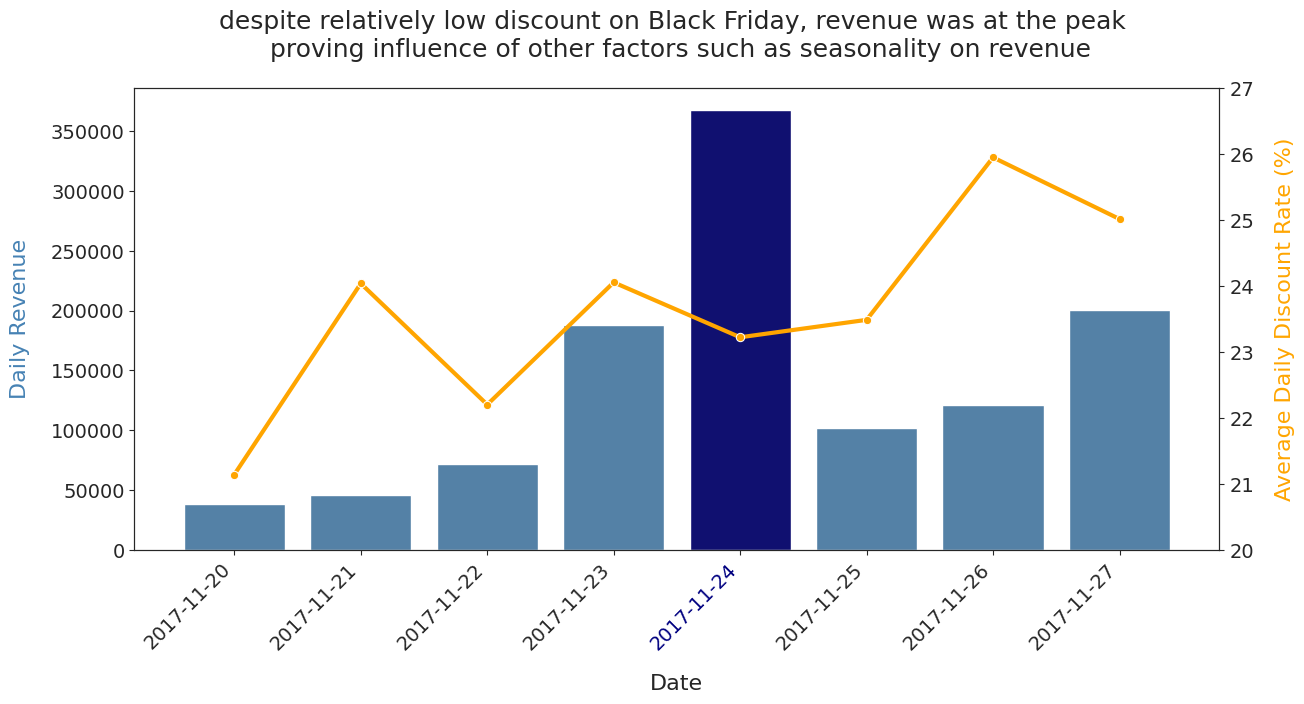

In [201]:
day_black_friday['date'] = day_black_friday['date'].astype(str)

my_days = {date: ("navy" if date == "2017-11-24" else "steelblue")
    for date in day_black_friday['date'].unique()}

sns.set_style("white", {'xtick.bottom': True})

fig, ax1 = plt.subplots(figsize=(14, 6))

bars = sns.barplot(data=day_black_friday, x='date', y='revenue', ax=ax1, palette=my_days, hue='date', legend=False)
ax1.set_ylabel('Daily Revenue', fontsize=16,labelpad=15,color='steelblue')
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel('Date',fontsize=16,labelpad=15)
ax1.tick_params(axis='x', labelsize=14)

#for container, count, date in zip(ax1.containers, day_black_friday['order_count'], day_black_friday['date']):
  #  labels = ax1.bar_label(container, labels=[count], padding=3,fontsize=11)
  #  color = 'navy' if date == '2017-11-24' else 'black'
  #  for label in labels:
  #      label.set_color(color)

ax2 = ax1.twinx()
sns.lineplot(data=day_black_friday, x='date', y='avg_discount_rate', ax=ax2, color='orange', marker='o',linewidth=3)
ax2.set_ylabel('Average Daily Discount Rate (%)', fontsize=16,labelpad=15,color='orange')
ax2.set_ylim(20, 27)
ax2.tick_params(axis='y', labelsize=14)
plt.title('despite relatively low discount on Black Friday, revenue was at the peak \n proving influence of other factors such as seasonality on revenue', fontsize=18,y=1.05)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
for label in ax1.get_xticklabels():
    if label.get_text() == '2017-11-24':
        label.set_color('navy')

plt.savefig('black_friday_chart.png', format='png', bbox_inches='tight')

#from google.colab import files
#files.download('black_friday_chart.png')

- Taking a look at months with the lowest discount rates and their performance (revenue-wise)

In [202]:
months = discounts_df.resample('ME', on='date').agg(
    revenue=('unit_total', 'sum'),
    avg_discount_rate=('discount_rate', 'mean'),
    order_count=('order_id', 'nunique')
).reset_index().nsmallest(6,'avg_discount_rate')
months['month_year'] = months['date'].dt.strftime('%B %Y')
months.sort_values(by='avg_discount_rate',ascending=True)

,date,revenue,avg_discount_rate,order_count,month_year
4,2017-05-31,335670.23,16.09,1691,May 2017
5,2017-06-30,287635.37,17.80,1367,June 2017
3,2017-04-30,233859.68,18.79,1488,April 2017
2,2017-03-31,25528.96,19.28,169,March 2017
11,2017-12-31,991494.12,19.73,4911,December 2017
1,2017-02-28,332471.05,19.85,2058,February 2017


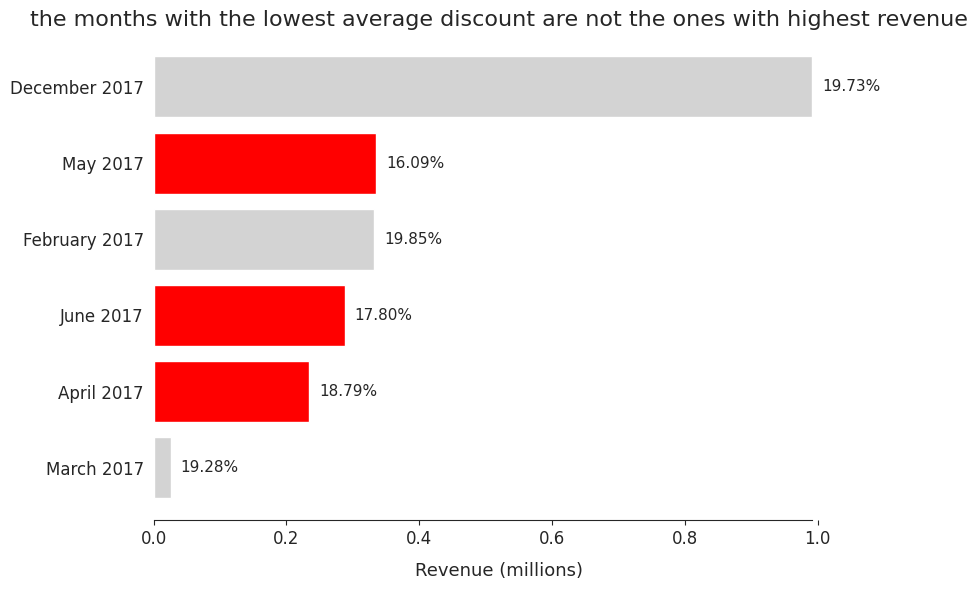

In [203]:
import matplotlib.ticker as ticker

# sort months by revenue
months_sorted = months.sort_values('revenue', ascending=False)

#get the lowest three in discount
lowest3 = months_sorted.nsmallest(3, 'avg_discount_rate')['month_year']
colors = ['red' if m in lowest3.values else 'lightgrey' for m in months_sorted['month_year']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(months_sorted['month_year'], months_sorted['revenue'], color=colors)

ax.invert_yaxis()

# add discount rate labels at the end of each bar
for bar, rate in zip(bars, months_sorted['avg_discount_rate']):
    ax.text(bar.get_width() + 15000, bar.get_y() + bar.get_height()/2,
             f'{rate:.2f}%', va='center', fontsize=11)

# AI heped out here: revenue in millions, no 1e6 offset text ---
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
ax.set_xlabel('Revenue (millions)', fontsize=13, labelpad=10)
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=12)

sns.despine(left=True, bottom=False) #keep bottom line
ax.spines['bottom'].set_bounds(0, months_sorted['revenue'].max())
plt.title('the months with the lowest average discount are not the ones with highest revenue',fontsize=16)
plt.tight_layout()
#save the plot and download
plt.savefig('months.png', format='png', bbox_inches='tight')
#from google.colab import files
#files.download('months.png')

## Question: How much of the data was used in % comparison to raw data

In [204]:
# Extracting the length of the original data (orderlines table)
url = "https://drive.google.com/file/d/1wA1iy62uEf0Y4kIa4FYBzegL7znIz3X8/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_original = pd.read_csv(path)
orderlines_original.shape[0]

293983

In [205]:
# Extracting the length of the data used for final analysis (orderlines table)
url = "https://drive.google.com/file/d/1h0QcOYBGLt2elCQPlecoc7nAn8lyoVdH/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_quality = pd.read_csv(path)
orderlines_quality.shape[0]

54125

In [206]:
useable = orderlines_quality.shape[0]/orderlines_original.shape[0]*100
print(f'The useable data was {useable:.2f}% of the raw data in the orderlines table')

The useable data was 18.41% of the raw data in the orderlines table


## Question: Correlation between discount and revenue

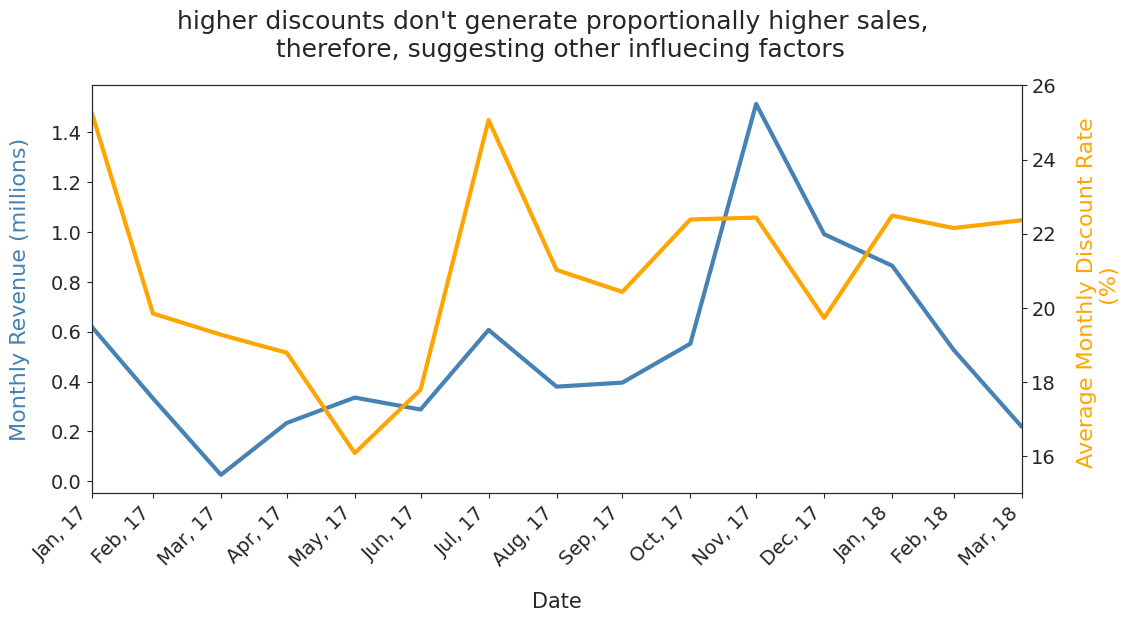

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [216]:
import matplotlib.dates as mdates

months_new = discounts_df.resample('ME', on='date').agg(
    discount_rate=('discount_rate', 'mean'),
    unit_total=('unit_total', 'sum')
).reset_index()

sns.set_style("white", {'xtick.bottom': True})

fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = sns.lineplot(data=months_new, x='date', y='unit_total', ax=ax1, color='steelblue', linewidth=3, legend=False)
ax1.set_ylabel('Monthly Revenue (millions)', fontsize=16, labelpad=15, color='steelblue')
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel('Date', fontsize=15, labelpad=15)
ax1.tick_params(axis='x', labelsize=14)

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))

# ticks anchored exactly to real monthly dates
ax1.xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(months_new['date'])))
ax1.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: mdates.num2date(x).strftime('%b, %y'))
)
ax1.margins(x=0)
ax1.set_xlim(months_new['date'].min(), months_new['date'].max())
fig.autofmt_xdate(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=months_new, x='date', y='discount_rate', ax=ax2, color='orange', linewidth=3, legend=False)
ax2.set_ylabel('Average Monthly Discount Rate \n (%)', fontsize=16, labelpad=15, color='orange')
ax2.set_ylim(15, 26)
ax2.tick_params(axis='y', labelsize=14)

plt.title("higher discounts don't generate proportionally higher sales, \n therefore, suggesting other influecing factors", fontsize=18, y=1.05)

plt.savefig('correlation_chart.png', format='png', bbox_inches='tight')
plt.show()
#from google.colab import files
#files.download('black_friday_chart.png')

## Question: Are refurbished, old, like new products discounted higher than new products?

In [208]:
discounts_df = discounts_df.copy()
discounts_df['category'] = ''
discounts_df.loc[discounts_df['desc'].str.contains(r"\b(refurbished|reconditioned|like new|old)\b", case=False), "category"] += ", not new"
not_new = discounts_df.loc[discounts_df['category'] == ', not new',:]

/tmp/ipykernel_2047/3627147819.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  discounts_df.loc[discounts_df['desc'].str.contains(r"\b(refurbished|reconditioned|like new|old)\b", case=False), "category"] += ", not new"


In [209]:
not_new['discount_rate'].max(), not_new['discount_rate'].min()

(91.97716562522503, -7.561436672967864)

In [210]:
new = discounts_df.loc[~(discounts_df['category'] == ', not new'),:]
new['discount_rate'].max(), new['discount_rate'].min()

(97.14081486776269, -212.26533166458074)

- at this point, no significant observation was made

## Data Exports

In [211]:
#from google.colab import drive
#drive.mount('/content/drive')

#import os

#save_path = "/content/drive/MyDrive/Data/Datasets/Present"
#os.makedirs(save_path, exist_ok=True)

#discounts_df.to_csv(f"{save_path}/discounts_df.csv", index=False)